In [1]:
# !pip install librosa
# !pip install transformers

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob
import numpy as np
import ast
import librosa
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [4]:
file_dir = r"/content/drive/MyDrive/deeplearning/Raw/Audio/WAV_16000/Segmented"
files = glob.glob(os.path.join(file_dir, "*.wav"))
print(f"총 오디오 파일 수: {len(files)}")

총 오디오 파일 수: 2199


In [5]:
sentiment_meta = r"/content/drive/MyDrive/deeplearning/mosi_audio_metadata.csv"
df = pd.read_csv(sentiment_meta)
print(df.head())

           file_name     audio_id  seg_idx  start_time   end_time  sentiment
0  03bSnISJMiM_1.wav  03bSnISJMiM        1   51.904533  55.945350       2.40
1  03bSnISJMiM_2.wav  03bSnISJMiM        2   56.045124  66.780720      -0.80
2  03bSnISJMiM_3.wav  03bSnISJMiM        3   66.780720  68.736280      -1.00
3  03bSnISJMiM_4.wav  03bSnISJMiM        4   68.736280  70.542175      -1.75
4  03bSnISJMiM_5.wav  03bSnISJMiM        5   70.542175  71.699550       0.00


In [7]:
def data_prepro(y, sr=16000):
  # 앞뒤 무음 구간 삭제
  y, idx = librosa.effects.trim(y, top_db=20)

  # 길이 8초 초과 -> 중앙 8초로 사용
  max_length= 8 * sr
  wav_length = len(y)

  if wav_length >  max_length:
    y= y[ wav_length//2 - int(max_length/2) : wav_length//2 + int(max_length/2) ]

  return y

In [8]:
from tqdm import tqdm

In [9]:
X, Y = [], []

for _, row in tqdm(df.iterrows()):
    p = os.path.join(file_dir, row["file_name"])
    y = row["sentiment"]

    aud, sr = librosa.load(p, sr=16000)

    X.append(aud)
    Y.append(y)

2199it [03:10, 11.53it/s]


In [35]:
y_class = [1 if y > 0 else 0 for y in Y]

In [38]:
X_prepro = []
for aud in X:
  X_prepro.append(data_prepro(aud))

In [39]:
# train / temp set 나누기
X_train, X_temp, y_train, y_temp = train_test_split(
    X_prepro, y_class,
    test_size=0.3,
    random_state=32,
    stratify=y_class
)

In [187]:
# 증강
def aug_noise20(y, snr_db=20):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    return y_noise

def aug_noise30(y, snr_db=30):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    return y_noise

def aug_pitch_h2(y, sr=16000, steps=2):
    y_pitchShift = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=steps)
    return y_pitchShift

def aug_noise20_pitch_h2(y,sr=16000,snr_db=20,steps=2):
    noise = np.random.randn(len(y)).astype(np.float32)
    scale = np.sqrt(np.mean(y**2) / (np.mean(noise**2) + 1e-12)) / (10 ** (snr_db / 20))
    y_noise = y + scale * noise
    y_noise_pitchShift = librosa.effects.pitch_shift(y=y_noise, sr=sr, n_steps=steps)
    return y_noise_pitchShift

In [40]:
X_noise20, X_pitch_h2, X_noise20_pitch_h2 =[], [], []
y_noise20, y_pitch_h2, y_noise20_pitch_h2 = [], [], []

for x,y in tqdm(zip(X_train, y_train)):
    X_noise20.append(aug_noise20(x))
    y_noise20.append(y)

    X_pitch_h2.append(aug_pitch_h2(x))
    y_pitch_h2.append(y)

    X_noise20_pitch_h2.append(aug_noise20_pitch_h2(x))
    y_noise20_pitch_h2.append(y)

In [188]:
X_noise30=[]
y_noise30=[]

for x,y in tqdm(zip(X_train, y_train)):
    X_noise30.append(aug_noise30(x))
    y_noise30.append(y)

1539it [00:02, 529.34it/s]


In [190]:
X_train_aug= X_train + X_noise20 + X_noise30 #X_pitch_h2 + X_noise20_pitch_h2
y_train_aug = y_train + y_noise20 + y_noise30 # y_pitch_h2 + y_noise20_pitch_h2

run_name='noise20 + noise30'

print("증강 전 데이터 개수:", len(X_train))
print("증강 후 데이터 개수:", len(X_train_aug))

증강 전 데이터 개수: 1539
증강 후 데이터 개수: 4617


In [16]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

wav_fe    = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
wav_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device).eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [191]:
train_features=[]
for i in tqdm(X_train_aug) :
    inputs = wav_fe(i, sampling_rate=16000, return_tensors="pt").to(device)
    with torch.no_grad():
        out = wav_model(**inputs)
    train_features.append(out.last_hidden_state.mean(dim=1).squeeze(0).cpu())

temp_features=[]
for i in tqdm(X_temp) :
    inputs = wav_fe(i, sampling_rate=16000, return_tensors="pt").to(device)
    with torch.no_grad():
        out = wav_model(**inputs)
    temp_features.append(out.last_hidden_state.mean(dim=1).squeeze(0).cpu())

100%|██████████| 660/660 [00:16<00:00, 40.78it/s]


In [192]:
train_features = torch.stack(train_features)
temp_features = torch.stack(temp_features)
train_features.shape

torch.Size([4617, 768])

In [193]:
class Classifier(nn.Module):
    def __init__(self, input_dim=768, shared_dim=256,  hidden_dim=128, num_classes=2):
        super().__init__()
        self.proj =nn.Linear(input_dim, shared_dim)

        self.classifier = nn.Sequential(
            nn.Linear(shared_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x= self.proj(x)
        x= self.classifier(x)
        return x

In [194]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [195]:
X_val, X_test, y_val, y_test = train_test_split(
    temp_features, y_temp,
    test_size=0.5,
    random_state=32,
    stratify=y_temp
)

In [197]:
train_loader = DataLoader(
    TensorDataset(train_features, torch.tensor(y_train_aug)),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, torch.tensor(np.array(y_val))),
    batch_size=64,
    shuffle=False
)

In [207]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Classifier(
    input_dim=train_features.shape[1],
    hidden_dim=128,
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-4)

early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001
)

num_epochs = 30

train_losses = []
val_losses = []
train_accs = []
val_accs = []


for epoch in range(num_epochs):
    model.train()

    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * y_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            val_loss_sum += loss.item() * y_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )
    early_stopping(val_loss)

    if early_stopping.early_stop:
        print("Early stopping")
        break

# history={
#     "train_loss": train_losses,
#     "val_loss": val_losses,
#     "train_acc": train_accs,
#     "val_acc": val_accs
# }

Epoch [1/30] Train Loss: 0.6884 | Train Acc: 0.5471 | Val Loss: 0.6792 | Val Acc: 0.5485
Epoch [2/30] Train Loss: 0.6707 | Train Acc: 0.5798 | Val Loss: 0.6750 | Val Acc: 0.5848
Epoch [3/30] Train Loss: 0.6573 | Train Acc: 0.6039 | Val Loss: 0.6725 | Val Acc: 0.5697
Epoch [4/30] Train Loss: 0.6526 | Train Acc: 0.6117 | Val Loss: 0.6938 | Val Acc: 0.5515
Epoch [5/30] Train Loss: 0.6556 | Train Acc: 0.6002 | Val Loss: 0.6620 | Val Acc: 0.5879
Epoch [6/30] Train Loss: 0.6333 | Train Acc: 0.6385 | Val Loss: 0.6646 | Val Acc: 0.6061
Epoch [7/30] Train Loss: 0.6247 | Train Acc: 0.6461 | Val Loss: 0.6703 | Val Acc: 0.6000
Epoch [8/30] Train Loss: 0.6394 | Train Acc: 0.6188 | Val Loss: 0.6635 | Val Acc: 0.6000
Epoch [9/30] Train Loss: 0.6165 | Train Acc: 0.6470 | Val Loss: 0.6637 | Val Acc: 0.6030
Epoch [10/30] Train Loss: 0.6320 | Train Acc: 0.6272 | Val Loss: 0.6734 | Val Acc: 0.5970
Early stopping


In [208]:
test_loader = DataLoader(
    TensorDataset(X_test, torch.tensor(y_test)),
    batch_size=64,
    shuffle=False
)

model.eval()

test_loss_sum = 0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)

        test_loss_sum += loss.item() * y_batch.size(0)

        preds = torch.argmax(logits, dim=1)

        test_correct += (preds == y_batch).sum().item()
        test_total += y_batch.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 최종 결과
test_loss = test_loss_sum / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

history={
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs,
    "test_acc": test_acc
}


Test Loss: 0.6632
Test Accuracy: 0.5939


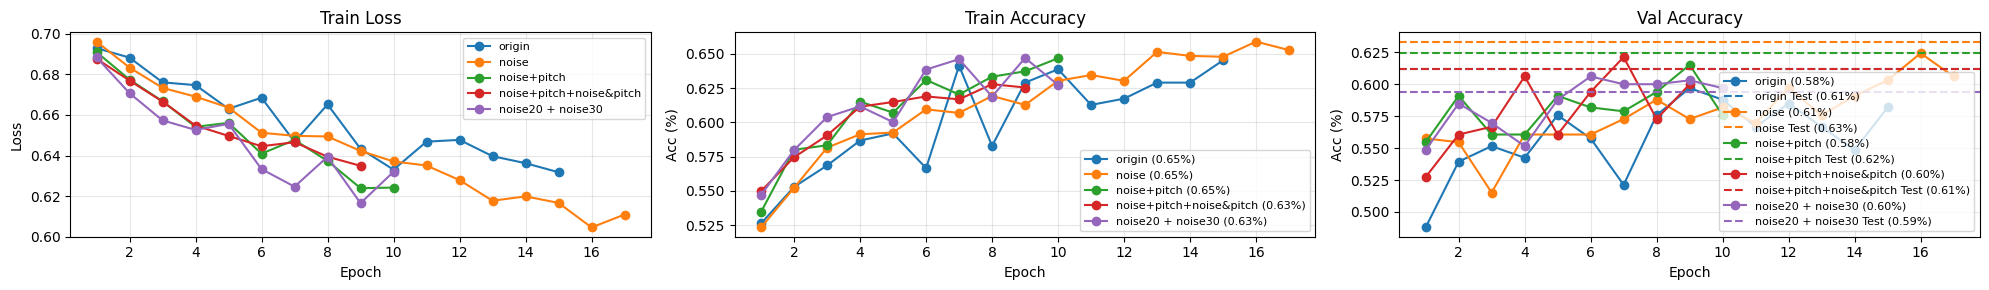


[noise20 + noise30] 최종 Test Acc: 0.59%
누적된 실험 (5개): ['origin', 'noise', 'noise+pitch', 'noise+pitch+noise&pitch', 'noise20 + noise30']


In [209]:
# 같은 이름이면 덮어씀 (중복 X)

if "assign_results" not in globals():
    assign_results = {}
    fig_a, ax_a = plt.subplots(1, 3, figsize=(20, 3))
    plt.close(fig_a)
assign_results[run_name] = history
from IPython.display import display

for ax in ax_a:
    ax.clear()
for name, h in assign_results.items():
    ep = range(1, len(h["train_loss"]) + 1)
    ax_a[0].plot(ep, h["train_loss"], "-o", label=name)
    ax_a[1].plot(ep, h["train_acc"], "-o", label=f"{name} ({h['train_acc'][-1]:.2f}%)")
    line=ax_a[2].plot(ep, h["val_acc"], "-o", label=f"{name} ({h['val_acc'][-1]:.2f}%)")[0]
    ax_a[2].axhline(y=h['test_acc'], linestyle="--", color=line.get_color(), label=f"{name} Test ({h['test_acc']:.2f}%)")

for ax in ax_a:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax_a[0].set_title("Train Loss"); ax_a[0].set_xlabel("Epoch"); ax_a[0].set_ylabel("Loss")
ax_a[1].set_title("Train Accuracy"); ax_a[1].set_xlabel("Epoch"); ax_a[1].set_ylabel("Acc (%)")
ax_a[2].set_title("Val Accuracy"); ax_a[2].set_xlabel("Epoch"); ax_a[2].set_ylabel("Acc (%)")
fig_a.tight_layout()
display(fig_a)

print(f"\n[{run_name}] 최종 Test Acc: {history['test_acc']:.2f}%")
print(f"누적된 실험 ({len(assign_results)}개): {list(assign_results.keys())}")

피처 저장

In [157]:
all_features=[]
for i in tqdm(X_prepro) :
    inputs = wav_fe(i, sampling_rate=16000, return_tensors="pt").to(device)
    with torch.no_grad():
        out = wav_model(**inputs)
    all_features.append(out.last_hidden_state.mean(dim=1).squeeze(0).cpu())

100%|██████████| 2199/2199 [00:50<00:00, 43.23it/s]


In [159]:
all_features = torch.stack(all_features)
all_features.shape

torch.Size([2199, 768])

In [160]:
#noise
x = all_features.to(device)

model.eval()

with torch.no_grad():
    proj_features = model.proj(x)

print(proj_features.shape)

torch.Size([2199, 256])


In [210]:
import pickle
save_data = {
    "audio_feat":  proj_features,
    "labels":   y_class,
}

In [211]:
with open('audio_feat_aug.pkl', 'wb') as f:
    pickle.dump(save_data, f)